# RANSAC line fitting + over-determined solution

- At the end we fit the line again using **all inliers at once**.
- Solved the **over-determined** problem with least squares.

## Step 1 — Imports and synthetic data *(copied)*

Half of the points lie (with Gaussian noise, σ = 10 px) on a line through `p` with direction `dir_`.
The other half are random outliers in the 640 × 480 image.

In [8]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

def init_random(seed=None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

def generate_data(N, p, direction, inlier_ratio=0.5):
    WIDTH, HEIGHT = 640, 480
    p = np.array(p, dtype=float)
    direction = np.array(direction, dtype=float)
    direction /= np.linalg.norm(direction)

    N_inlier = int(N * inlier_ratio)
    N_outlier = N - N_inlier

    points = []

    diag = np.sqrt(WIDTH**2 + HEIGHT**2)
    for _ in range(N_inlier):
        t = (random.random() * diag) - diag / 2.0
        q = p + t * direction
        q[0] += np.random.normal(0.0, 10.0)
        q[1] += np.random.normal(0.0, 10.0)
        points.append(q)

    for _ in range(N_outlier):
        points.append((random.random() * WIDTH, random.random() * HEIGHT))

    return np.array(points, dtype=float)

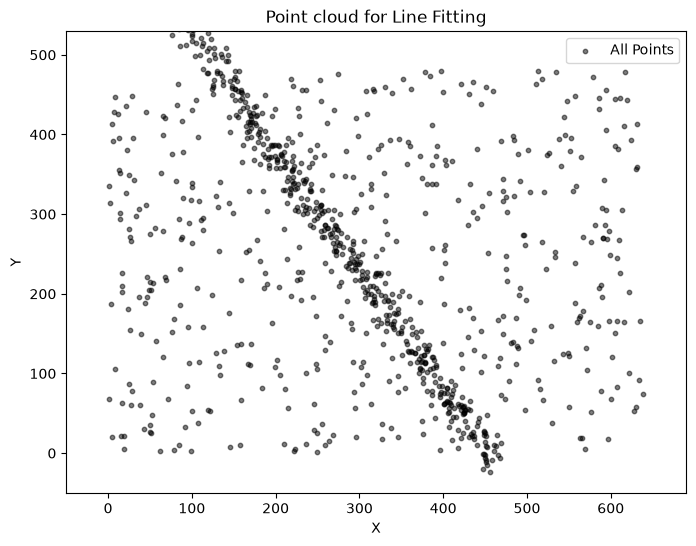

In [9]:
init_random(seed=0)

N = 1000
p = (240.0, 320.0)
alpha = random.random() * 2.0 * np.pi
dir_ = (np.cos(alpha), np.sin(alpha))
points = generate_data(N, p, dir_, inlier_ratio=0.5)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(points[:, 0], points[:, 1], s=10, c='k', alpha=0.5, label='All Points')
ax.set_xlim([-50, 690])
ax.set_ylim([-50, 530])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Point cloud for Line Fitting')
ax.legend()
plt.show()

## Step 2 — Line helpers *(copied)*

* `fit_line_two_points`: line $ax + by + c = 0$ through two points, normalised so $a^2 + b^2 = 1$.
* `distance_point_line`: because the line is normalised, the perpendicular distance is simply $|ax + by + c|$.
* `iteration_number`: how many random samples RANSAC needs for the given confidence,
  $k = \left\lceil \frac{\ln(1-p)}{\ln(1-w^s)} \right\rceil$.

In [10]:
def fit_line_two_points(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    dx, dy = x2 - x1, y2 - y1
    norm = math.sqrt(dx**2 + dy**2)
    if norm < 1e-8:
        return None
    a, b = -dy / norm, dx / norm
    c = -a * x1 - b * y1
    return a, b, c

def distance_point_line(line_params, point):
    a, b, c = line_params
    x, y = point
    return abs(a*x + b*y + c)

In [11]:
def iteration_number(confidence, sample_size, inliers, N):
    if inliers == 0:
        return float('inf')
    ratio = inliers / float(N)
    top = math.log(1.0 - confidence)
    bottom = math.log(1.0 - ratio**sample_size)
    return math.ceil(top / bottom) if bottom != 0 else float('inf')

## Step 3 — RANSAC

The number of iteration was "fixed" with the for loop, that's why I used the WHILE instead so I can control the MAX ITERATION limit

In [12]:
def ransac_line(points, max_iterations=2000, sigma=10.0, confidence=0.95, verbose=True):
    best_inliers_count = 0
    best_line, best_inliers_list = None, []

    i = 0
    while i < max_iterations:
        i += 1
        idx1, idx2 = np.random.choice(len(points), 2, replace=False)
        line_params = fit_line_two_points(points[idx1], points[idx2])
        if line_params is None:
            continue

        inliers = [pt for pt in points if distance_point_line(line_params, pt) < sigma]

        if len(inliers) > best_inliers_count:
            best_inliers_count, best_line, best_inliers_list = len(inliers), line_params, inliers
            max_iterations = min(max_iterations, iteration_number(confidence, 2, best_inliers_count, len(points)))

    if verbose:
        print(f"RANSAC stopped after {i} iterations")
    return best_line, np.array(best_inliers_list)

## Over-determined solution (least squares on all inliers)

Every inlier $(x_i, y_i)$ should satisfy $a x_i + b y_i + c = 0$. With $n$ inliers that is
$n$ equations but only 3 unknowns, so we look for the line that makes the total error smallest:

$$
\min_{a,b,c} \sum_{i=1}^{n} (a x_i + b y_i + c)^2 \quad \text{subject to} \quad a^2 + b^2 = 1
$$

Because $a^2 + b^2 = 1$, each term is the squared perpendicular distance of a point to the line.

**1. Find $c$.** Setting the derivative with respect to $c$ to zero gives
$c = -(a\bar{x} + b\bar{y})$, so the best line always passes through the **centroid** $(\bar{x}, \bar{y})$.

**2. Find $(a, b)$.** Substituting $c$ back, we need to minimise $\|A\,\mathbf{n}\|^2$ with $\|\mathbf{n}\| = 1$, where

$$
A = \begin{bmatrix} x_1 - \bar{x} & y_1 - \bar{y} \\ \vdots & \vdots \\ x_n - \bar{x} & y_n - \bar{y} \end{bmatrix},
\qquad \mathbf{n} = \begin{bmatrix} a \\ b \end{bmatrix}
$$

The solution is the eigenvector of $A^T A$ with the **smallest** eigenvalue, which is the last row of
$V^T$ in the SVD of $A$. Intuition: the normal of the line points in the direction where the inliers
spread the **least**.

In [13]:
def fit_line_least_squares(pts):
    centroid = pts.mean(axis=0)             # the best line goes through the centroid
    A = pts - centroid                      # one row per inlier: (x_i - x_mean, y_i - y_mean)
    _, _, Vt = np.linalg.svd(A)
    a, b = Vt[-1]                           # direction of smallest spread = unit normal (a, b)
    c = -(a * centroid[0] + b * centroid[1])
    return a, b, c

## Step 5 — Run RANSAC, then refine with all inliers

Two ways to compare the lines:

* **RMS distance of the inliers** to the line: how well the line fits the inliers.
  Least squares minimises exactly this, so the refined line can never be worse here.
* **Angle error** with respect to the true line (we know it because the data is synthetic):
  the angle between the fitted normal $(a, b)$ and the true normal $(-d_y, d_x)$.

In [14]:
ransac_line_params, inliers = ransac_line(points)
refined_line = fit_line_least_squares(inliers)

def rms_distance(line_params, pts):
    return np.sqrt(np.mean([distance_point_line(line_params, pt)**2 for pt in pts]))

def angle_error(line_params, direction):
    a, b, c = line_params
    cos_angle = abs(a * -direction[1] + b * direction[0])   # |fitted normal . true normal|
    return np.degrees(np.arccos(min(cos_angle, 1.0)))

print(f"Number of inliers: {len(inliers)} out of {len(points)}")
print("RANSAC line  (2 points):    a={:.3f}, b={:.3f}, c={:.3f}".format(*ransac_line_params))
print("Refined line (all inliers): a={:.3f}, b={:.3f}, c={:.3f}".format(*refined_line))
print()
print(f"RMS inlier distance - RANSAC:  {rms_distance(ransac_line_params, inliers):.2f} px")
print(f"RMS inlier distance - refined: {rms_distance(refined_line, inliers):.2f} px")
print(f"Angle error - RANSAC:  {angle_error(ransac_line_params, dir_):.2f} deg")
print(f"Angle error - refined: {angle_error(refined_line, dir_):.2f} deg")

RANSAC stopped after 23 iterations
Number of inliers: 354 out of 1000
RANSAC line  (2 points):    a=-0.834, b=-0.552, c=376.176
Refined line (all inliers): a=-0.833, b=-0.553, c=376.185

RMS inlier distance - RANSAC:  5.50 px
RMS inlier distance - refined: 5.49 px
Angle error - RANSAC:  0.46 deg
Angle error - refined: 0.39 deg


## Step 6 — Results

The plot uses the same drawing code as the original ($y = (-ax - c)/b$), wrapped in a small helper so we can draw both lines.

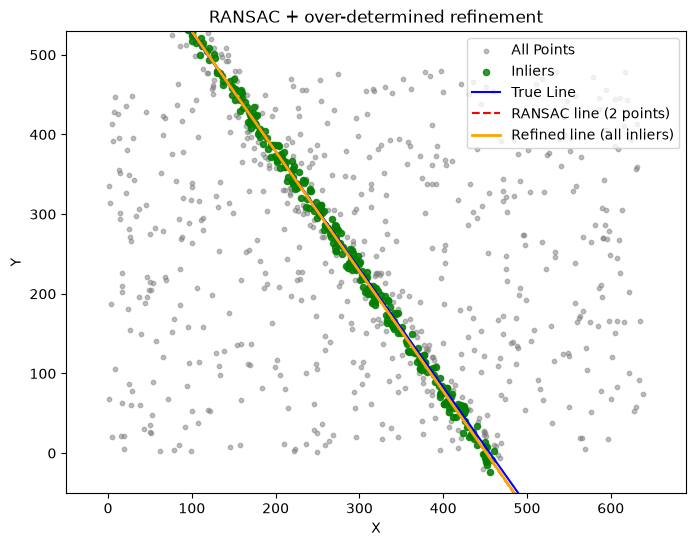

In [15]:
def draw_line(ax, line_params, **kwargs):
    a, b, c = line_params
    x_vals = np.linspace(0, 640, 2)
    y_vals = (-a*x_vals - c) / b
    ax.plot(x_vals, y_vals, **kwargs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(points[:, 0], points[:, 1], s=10, c='gray', alpha=0.5, label='All Points')
ax.scatter(inliers[:, 0], inliers[:, 1], s=20, c='green', alpha=0.8, label='Inliers')

p1 = (p[0] - 1000*dir_[0], p[1] - 1000*dir_[1])
p2 = (p[0] + 1000*dir_[0], p[1] + 1000*dir_[1])
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], c='blue', label='True Line')

draw_line(ax, ransac_line_params, c='red', ls='--', label='RANSAC line (2 points)')
draw_line(ax, refined_line, c='orange', lw=2, label='Refined line (all inliers)')

ax.set_xlim([-50, 690])
ax.set_ylim([-50, 530])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('RANSAC + over-determined refinement')
ax.legend()
plt.show()

## Step 7 — *(optional)* Does the refinement help on average?

In a single run the two lines can be almost identical (if RANSAC happened to pick two very good points).
Repeating the experiment on 20 different random datasets shows the average effect.

In [16]:
errors_ransac, errors_refined = [], []
for seed in range(20):
    init_random(seed)
    alpha = random.random() * 2.0 * np.pi
    d = (np.cos(alpha), np.sin(alpha))
    pts = generate_data(N, p, d, inlier_ratio=0.5)

    line_r, inl = ransac_line(pts, verbose=False)
    line_ls = fit_line_least_squares(inl)

    errors_ransac.append(angle_error(line_r, d))
    errors_refined.append(angle_error(line_ls, d))

print(f"Mean angle error over 20 runs - RANSAC:  {np.mean(errors_ransac):.2f} deg")
print(f"Mean angle error over 20 runs - refined: {np.mean(errors_refined):.2f} deg")

Mean angle error over 20 runs - RANSAC:  0.47 deg
Mean angle error over 20 runs - refined: 0.36 deg
